In [1]:
### importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Connecting to the SQL Database

In [2]:
import sqlite3

In [3]:
connection = sqlite3.connect('C:\\Users\\Admin\\Desktop\\Shift-Optimization-System\\shiftData.db')
shift_data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
shift_data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


#### Basic Data Overview

In [4]:
shift_data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [5]:
shift_data.shape

(296334, 31)

In [6]:
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [7]:
#formatting the date column into proper format from object

shift_data['date'] = pd.to_datetime(shift_data['date'])
shift_data['start_time'] = pd.to_datetime(shift_data['start_time'])
shift_data['end_time'] = pd.to_datetime(shift_data['end_time'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_12332\286065483.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shift_data['start_time'] = pd.to_datetime(shift_data['start_time'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_12332\286065483.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  shift_data['end_time'] = pd.to_datetime(shift_data['end_time'])


In [8]:
shift_data['timestamp'] = pd.to_datetime(shift_data['timestamp'])

In [9]:
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [10]:
#checking for duplicates

shift_data.duplicated().sum()

np.int64(0)

In [11]:
# checking for missing values

shift_data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [12]:
# check statistical summary of the data

shift_data.describe()

,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity,timestamp
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000,295129
mean,2.048142,2026-05-31 14:23:06.478770688,2026-05-31 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118,2024-02-15 04:22:59.795276288
min,1.000000,2026-05-31 06:00:00,2026-05-31 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000,2024-01-01 08:00:00
25%,1.000000,2026-05-31 06:00:00,2026-05-31 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000,2024-01-23 08:00:00
50%,2.000000,2026-05-31 14:00:00,2026-05-31 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000,2024-02-15 00:00:00
75%,3.000000,2026-05-31 22:00:00,2026-05-31 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000,2024-03-09 00:00:00
max,3.000000,2026-05-31 22:00:00,2026-05-31 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000,2024-03-31 16:00:00
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084,NaN


#### Filling the missing values

In [13]:
#sorting the dataset chronologically
shift_data = shift_data.sort_values(by='date')

#filling temperature and humidity columns
shift_data['temperature'] = shift_data['temperature'].fillna(method='ffill').fillna(shift_data['temperature'].mean())
shift_data['humidity'] = shift_data['humidity'].fillna(method='ffill').fillna(shift_data['humidity'].mean())

#fill timestamp
shift_data['timestamp'] = shift_data['timestamp'].fillna(method='ffill')


C:\Users\Admin\AppData\Local\Temp\ipykernel_12332\434580701.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data['temperature'] = shift_data['temperature'].fillna(method='ffill').fillna(shift_data['temperature'].mean())
C:\Users\Admin\AppData\Local\Temp\ipykernel_12332\434580701.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data['humidity'] = shift_data['humidity'].fillna(method='ffill').fillna(shift_data['humidity'].mean())
C:\Users\Admin\AppData\Local\Temp\ipykernel_12332\434580701.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  shift_data['timestamp'] = shift_data['timestamp'].fillna(method='ffill')


In [14]:
shift_data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [15]:
# filling the remaining missing categorical fields

shift_data['issue_type'] = shift_data['issue_type'].fillna('No Issue')
shift_data['resolved_by'] = shift_data['resolved_by'].fillna('No Maintenance')

#filling the downtime column with 0 as it indicates no downtime when there is no issue
shift_data['maintenance_downtime'] = shift_data['maintenance_downtime'].fillna(0)

shift_data = shift_data.drop(columns=['maintenance_id'])

In [16]:
shift_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [17]:
shift_data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

### Exploratory Data Analysis

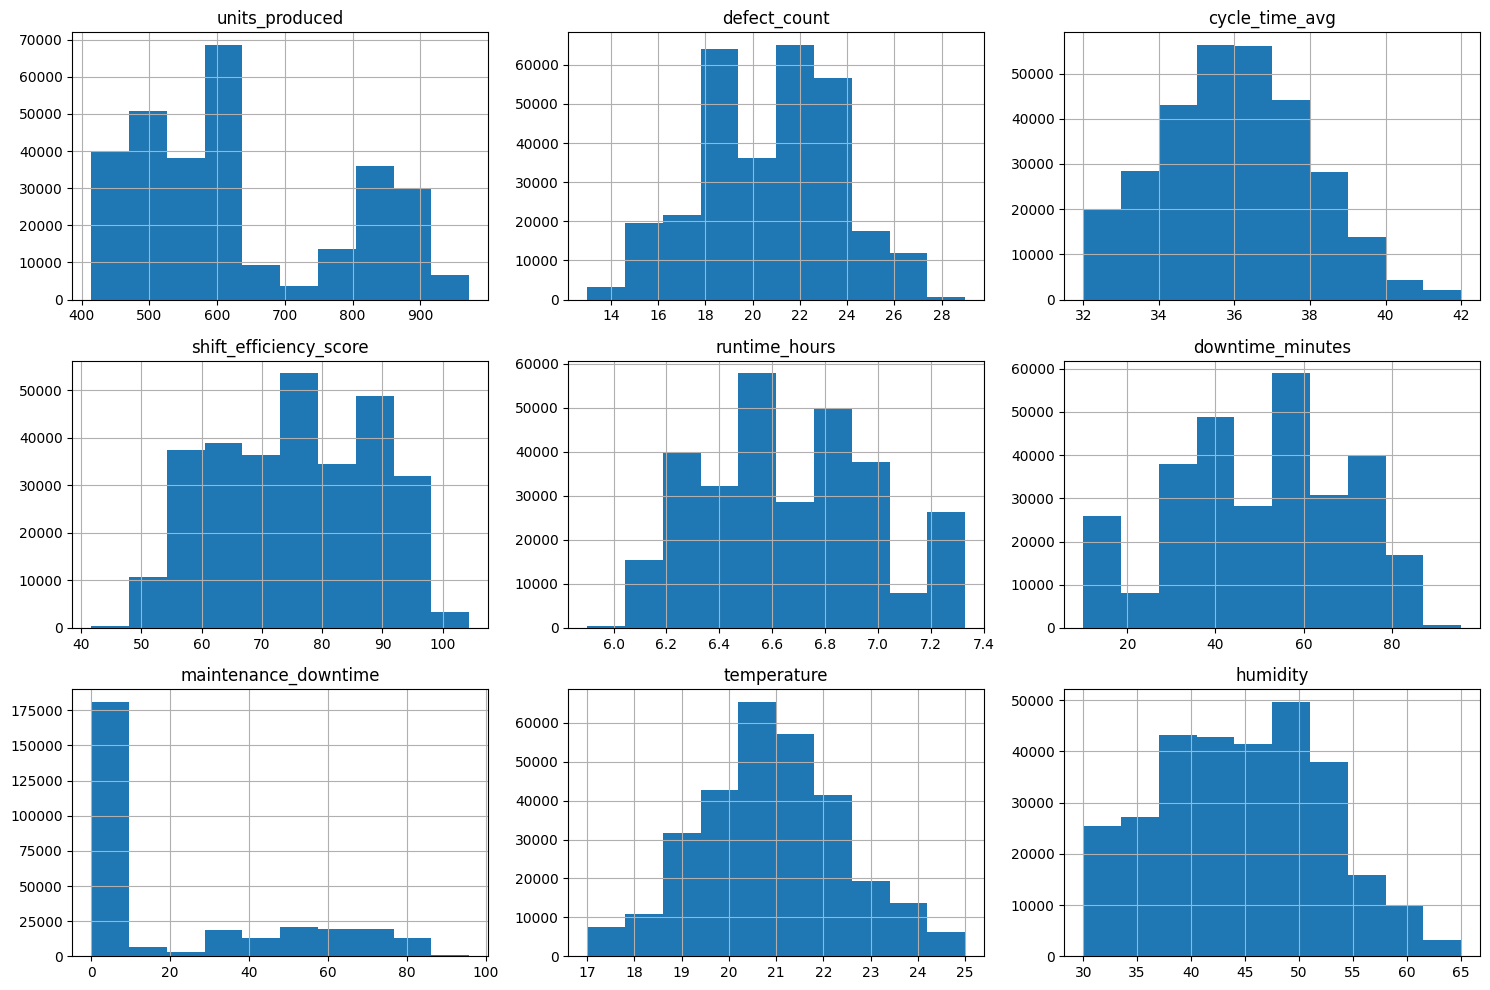

In [18]:
## Numerical data distribution
num_cols = [
    'units_produced', 'defect_count', 'cycle_time_avg', 
    'shift_efficiency_score', 'runtime_hours', 'downtime_minutes', 'maintenance_downtime',
    'temperature', 'humidity'
]

shift_data[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

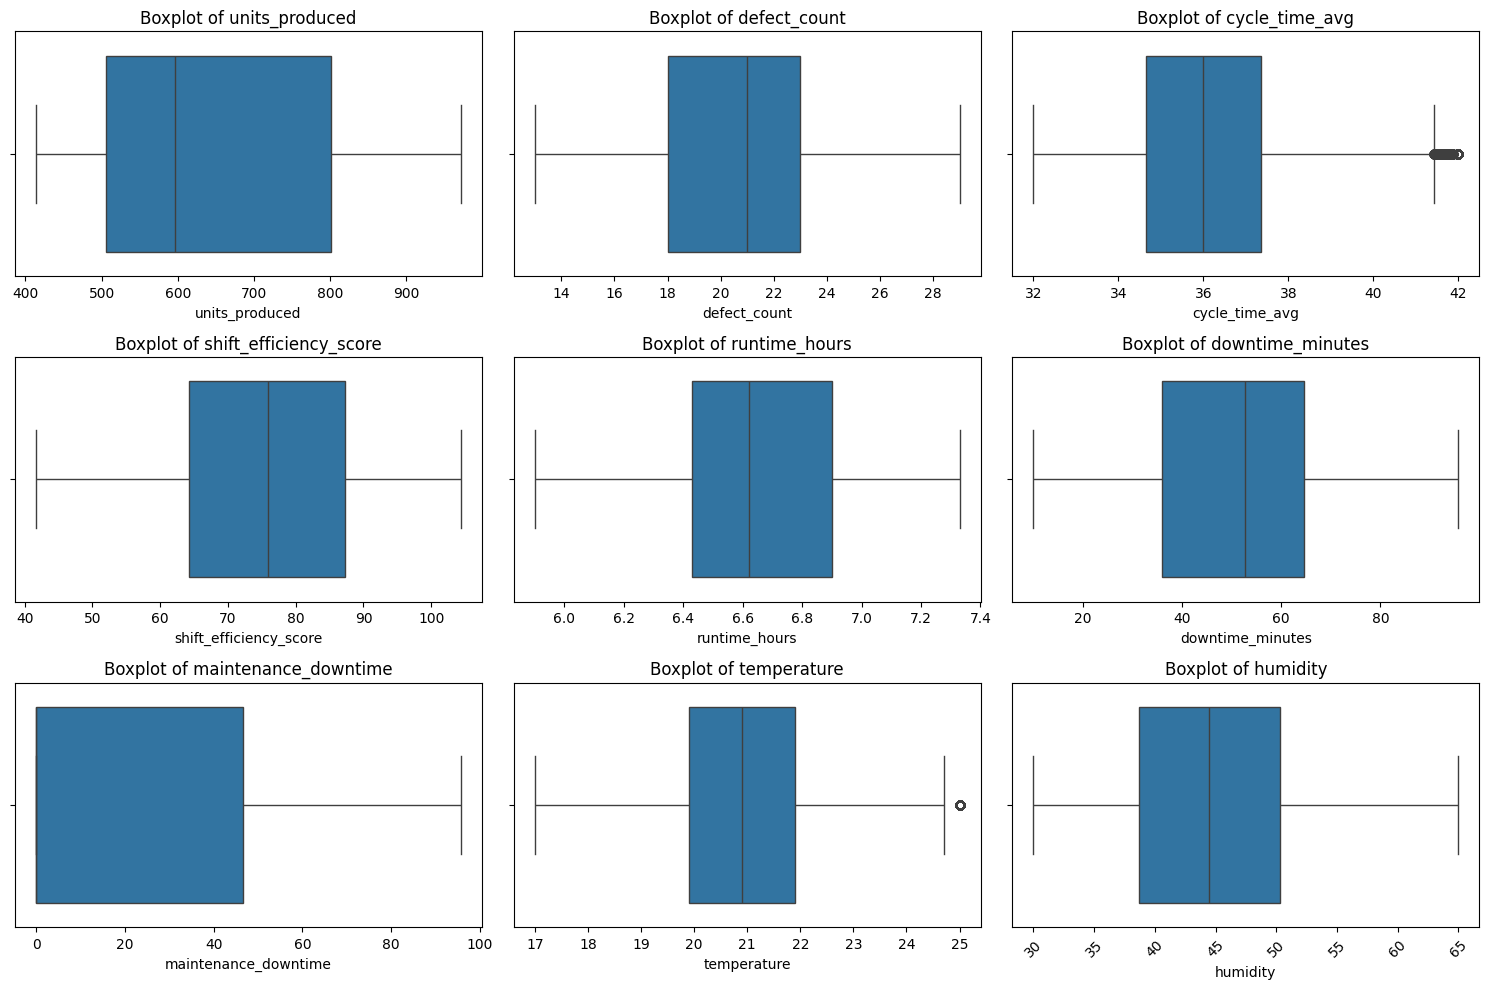

In [19]:
## Using boxplot to check if dataset has outliers

plt.figure(figsize = (15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=shift_data[col])
    plt.title(f'Boxplot of {col}')
    
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Categorical Variable Analysis

In [20]:
cat_cols = [
    'shift_name', 'issue_type', 'resolved_by',
    'machine_status', 'defect_type', 'inspection_result',
    'severity', 'experience_level'
    ]

for col in cat_cols:
    print(f'Value counts for {col}:\n{shift_data[col].value_counts()}\n')
    print(shift_data[col].value_counts())
    

Value counts for shift_name:
shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
Value counts for issue_type:
issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64

issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
Value counts for resolved_by:
resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07            12427
TECH_08            12290
TECH_02            12065
TECH_10            11977
TECH_05            11743
TECH_04            11275
TECH_01            10522
TECH_09            10441
TECH_06             9954
Name: count, dtype: int64

resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07       

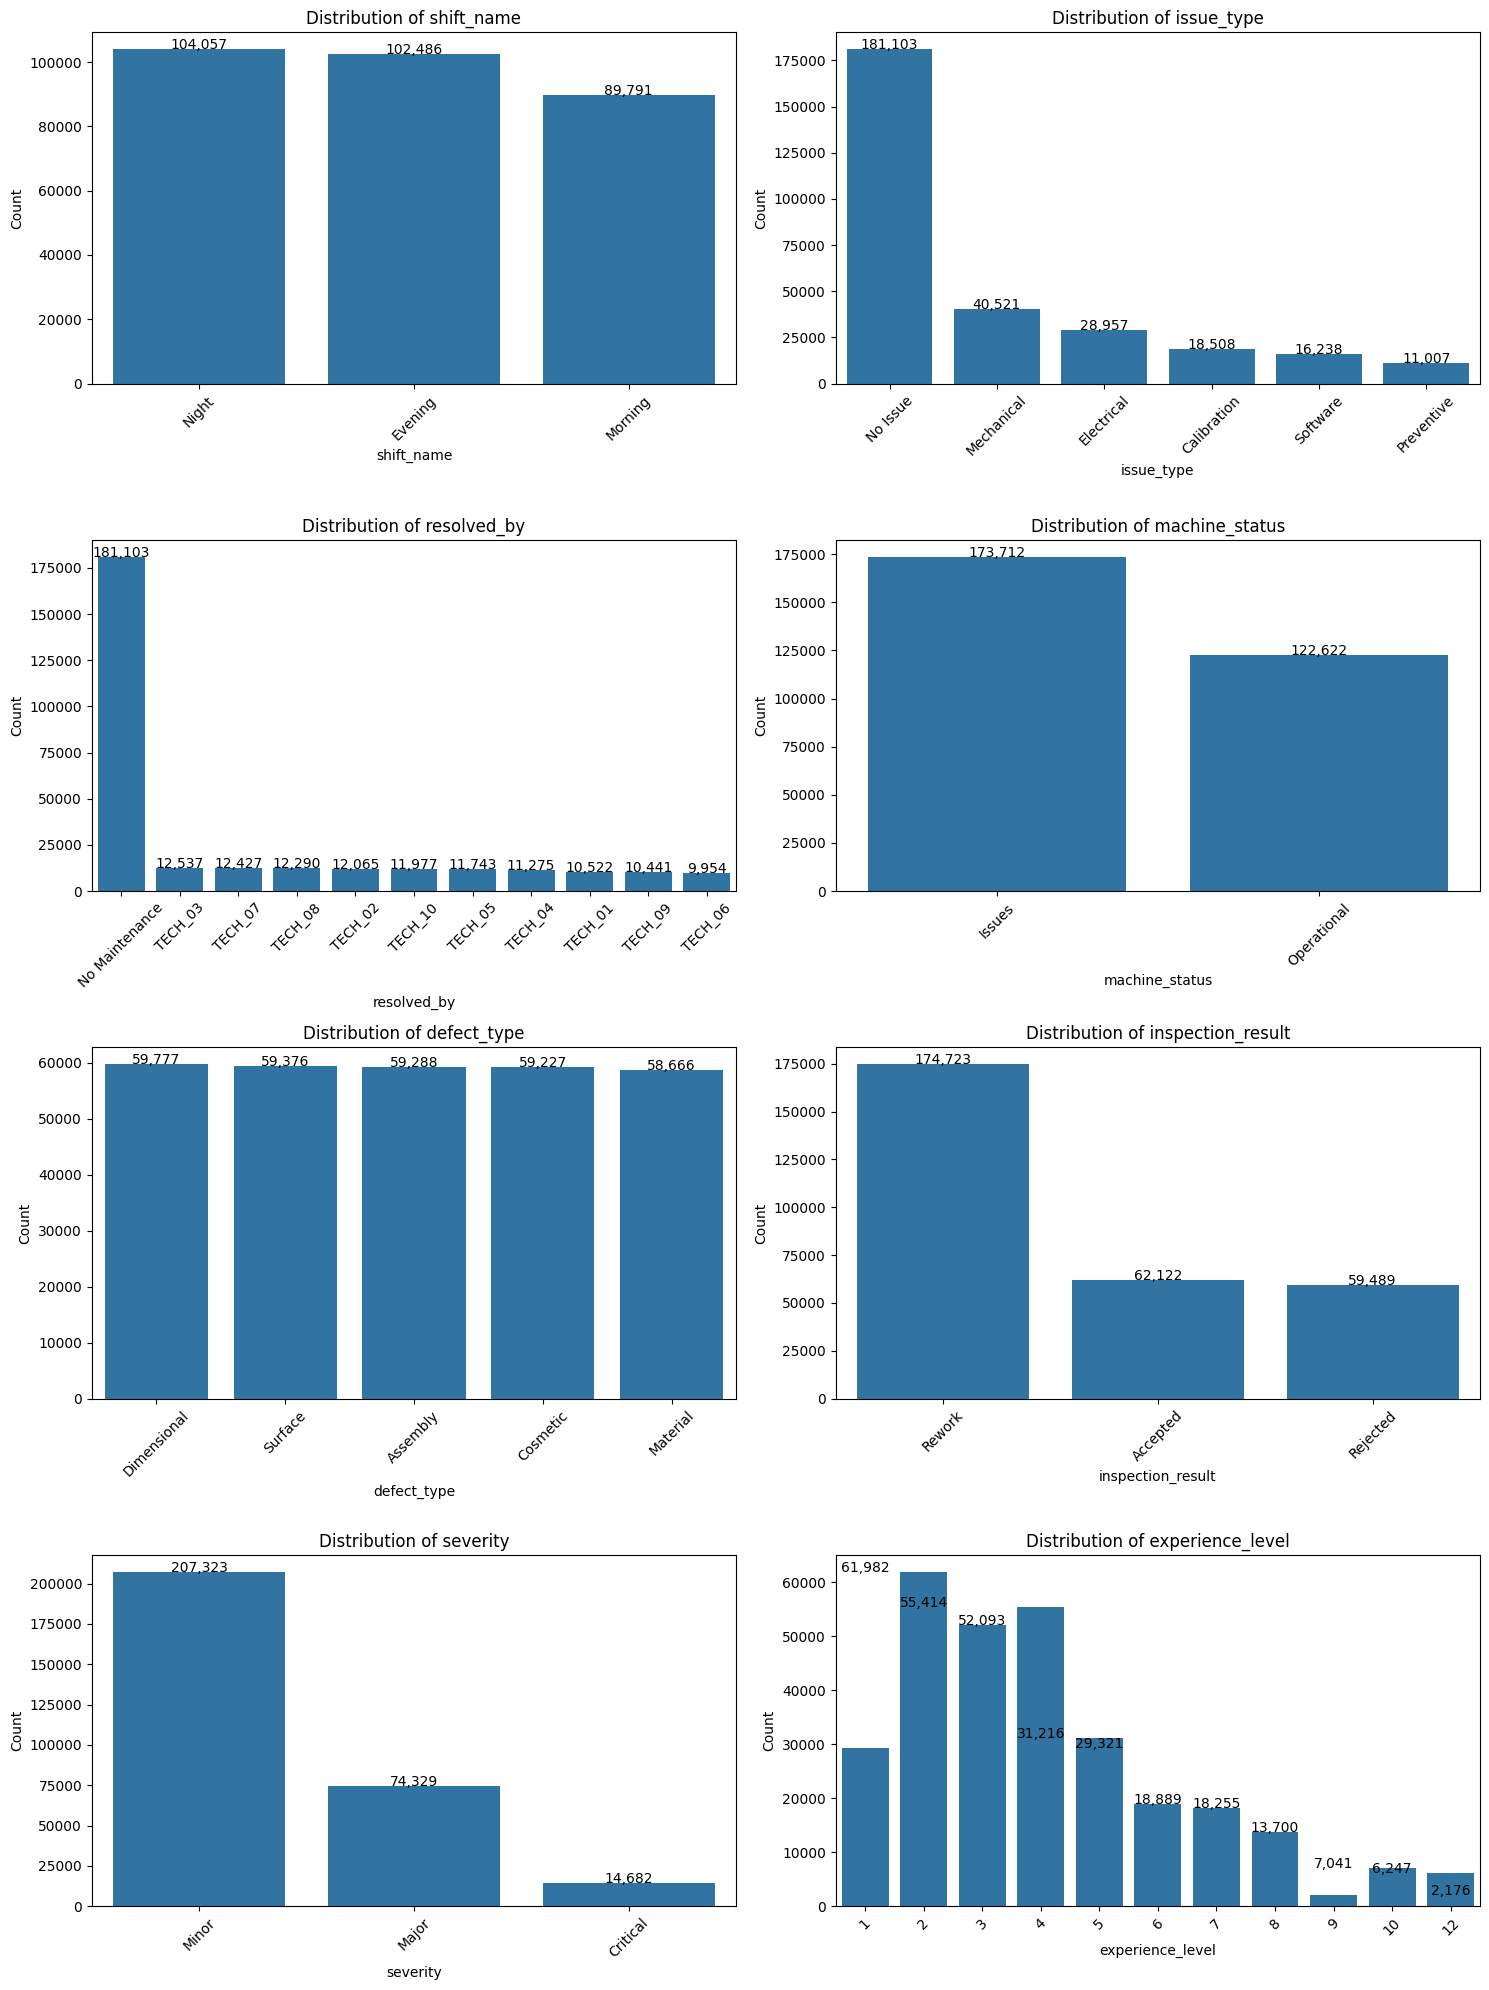

In [21]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()
for index, column in enumerate(cat_cols):
    # get the column count
    counts = shift_data[column].value_counts().reset_index()
    counts.columns = [column, 'count']

    sns.barplot(x=column, y='count', data=counts, ax=axes[index])
    
    # plot customisation
    axes[index].tick_params(axis='x', rotation=45)
    axes[index].set_title(f'Distribution of {column}')
    axes[index].set_xlabel(column)
    axes[index].set_ylabel('Count')

    # add count labels on top of bars
    for j, v in enumerate(counts['count']):
        axes[index].text(j, v, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

#### Operational performance during maintenance and with no maintenence

In [22]:
# maintenance analysis
maintenance_data = shift_data.groupby('maintenance_flag')[num_cols].mean()

In [23]:
maintenance_data.head(5)

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
maintenance_flag,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,49.281488,13.520254,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.954773,53.701075,20.860356,44.613007


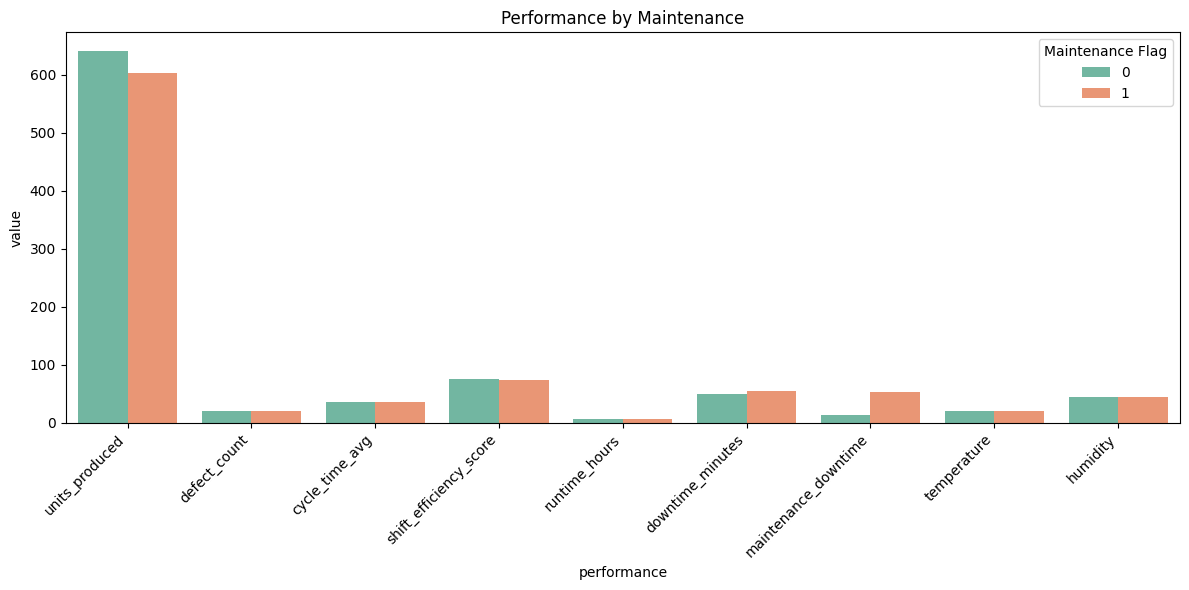

In [24]:
maintenance_plot = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_plot.melt(
    id_vars = 'maintenance_flag', 
    var_name= 'performance', 
    value_name='value')

plt.figure(figsize=(12, 6))
sns.barplot(
    x='performance', 
    y='value', 
    hue='maintenance_flag', 
    data=maintenance_plot_melt,
    palette='Set2'
)
plt.xticks(rotation=45, ha='right')
plt.title('Performance by Maintenance')
plt.legend(title='Maintenance Flag')
plt.tight_layout()
plt.show()

#### Shift Performance Analysis

In [25]:
shift_performance_data = shift_data.groupby('shift_name').agg({
    "units_produced": ["mean", "sum"],
    "cycle_time_avg": "mean",
    "defect_count": "mean",
    "downtime_minutes": ["mean", "sum"],
    "shift_efficiency_score": "mean"
}).reset_index()

shift_performance_data.columns = ['shift_name', 
                                  'average_units_produced', 
                                  'total_units_produced', 
                                  'average_cycle_time', 
                                  'average_defect_count', 
                                  'average_downtime', 
                                  'total_downtime', 
                                  'average_efficiency']

# calculate defect rate
defect_sum = shift_data.groupby('shift_name')['defect_count'].sum().values
units_sum = shift_data.groupby('shift_name')['units_produced'].sum().values

shift_performance_data['defect_rate'] = (defect_sum / units_sum) * 100

shift_performance_data.sort_values(by='average_units_produced', ascending=False)


,shift_name,average_units_produced,total_units_produced,average_cycle_time,average_defect_count,average_downtime,total_downtime,average_efficiency,defect_rate
1,Morning,846.926073,76046339,35.999287,18.749151,29.086002,2611661.18,90.869944,2.213788
0,Evening,601.050543,61599266,36.025551,21.329079,50.569570,5182672.96,76.737957,3.548633
2,Night,484.765119,50443204,36.028043,21.670998,67.857893,7061088.73,61.164965,4.470412


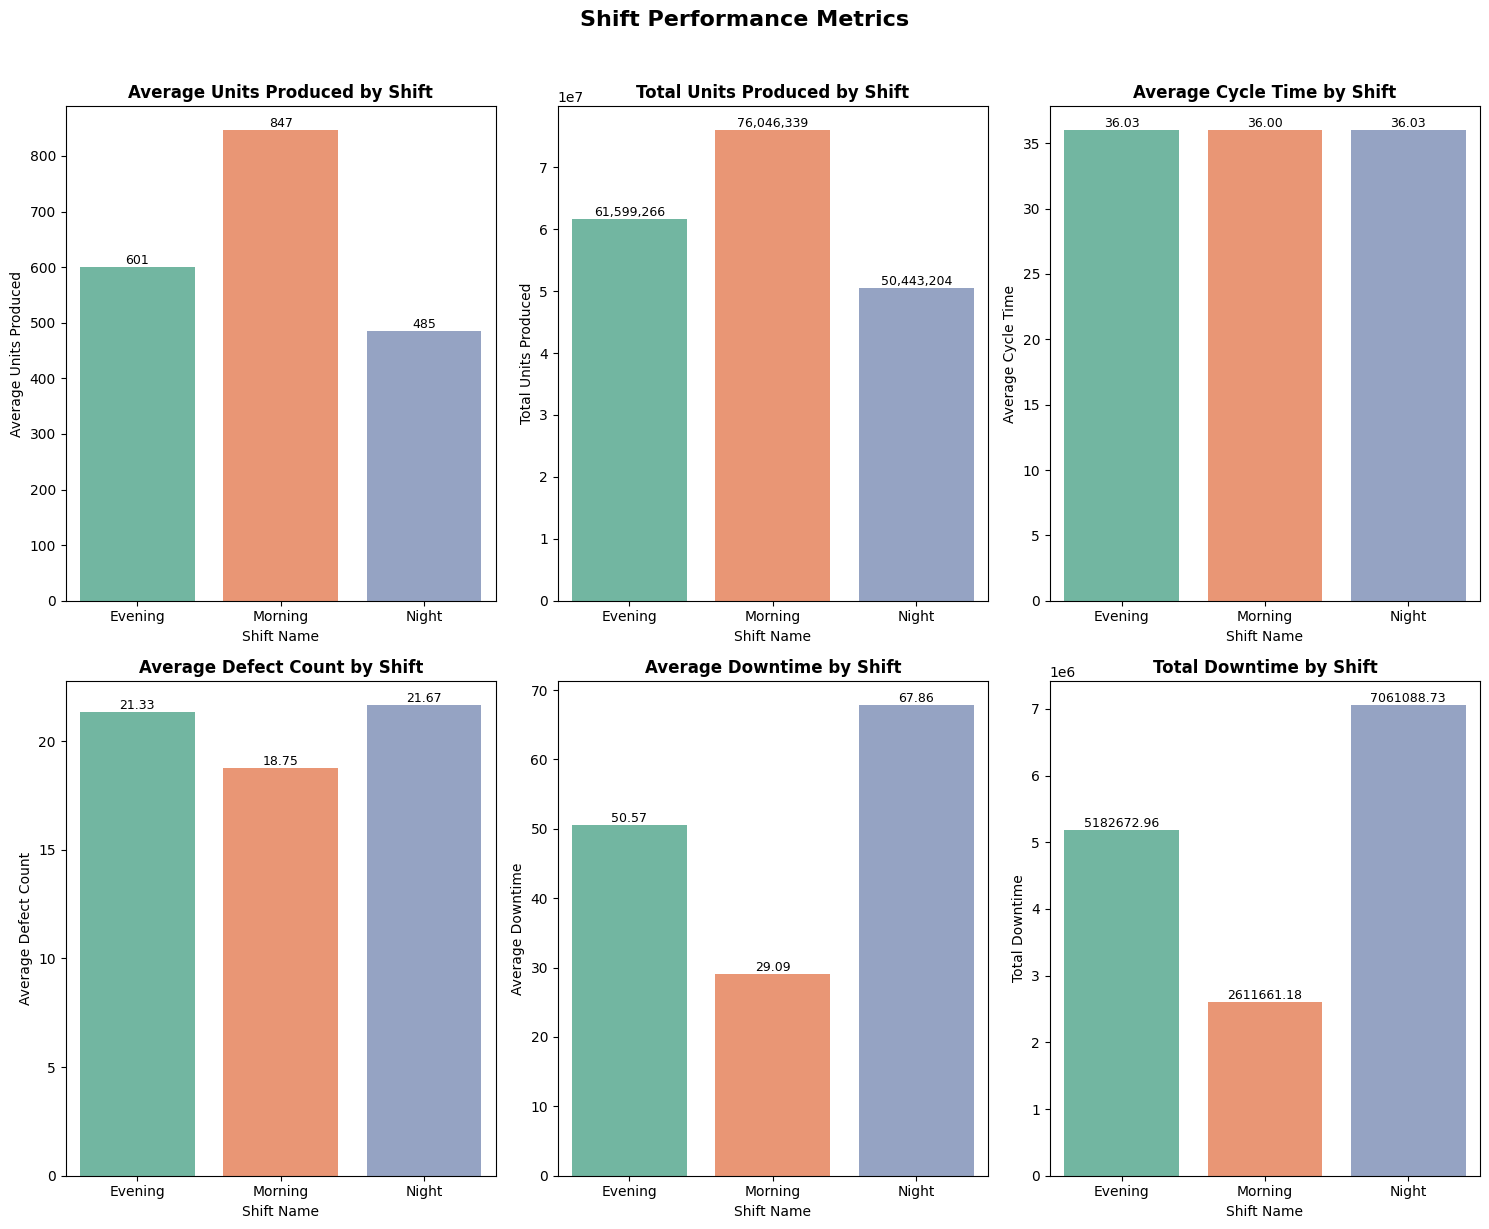

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()
matrics = ["average_units_produced", "total_units_produced", "average_cycle_time", "average_defect_count", "average_downtime", "total_downtime"]
for i, metric in enumerate(matrics):
    sns.barplot(data = shift_performance_data,
                    x = 'shift_name',
                    y = metric,
                    hue = 'shift_name',
                    palette = 'Set2',
                    legend = False,
                    ax = axes[i])
    axes[i].set_title(f'{metric.replace("_", " ").title()} by Shift', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Shift Name')
    axes[i].set_ylabel(metric.replace("_", " ").title())

    for j, v in enumerate(shift_performance_data[metric]):
        if 'units' in metric:
            axes[i].text(j, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)
        else:
            axes[i].text(j, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)  

plt.suptitle('Shift Performance Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Shift Performance based on production output per hour

In [27]:
shift_data['total_operation_hours'] = shift_data['runtime_hours'] + (shift_data['downtime_minutes'] / 60)

output_per_hour = shift_data.groupby('shift_name').apply(lambda x: x['units_produced'].sum() / x['total_operation_hours'].sum())

output_per_hour

C:\Users\Admin\AppData\Local\Temp\ipykernel_12332\2852359934.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  output_per_hour = shift_data.groupby('shift_name').apply(lambda x: x['units_produced'].sum() / x['total_operation_hours'].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
dtype: float64

In [28]:
output_per_hour_data = output_per_hour.reset_index()

In [29]:
output_per_hour_data.columns

output_per_hour_data[0] = output_per_hour_data[0].rename('output_per_hour', inplace=True)

In [30]:
output_per_hour_data = output_per_hour_data.rename(columns={0: 'output_per_hour'})

In [31]:
output_per_hour_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   shift_name       3 non-null      object 
 1   output_per_hour  3 non-null      float64
dtypes: float64(1), object(1)
memory usage: 180.0+ bytes


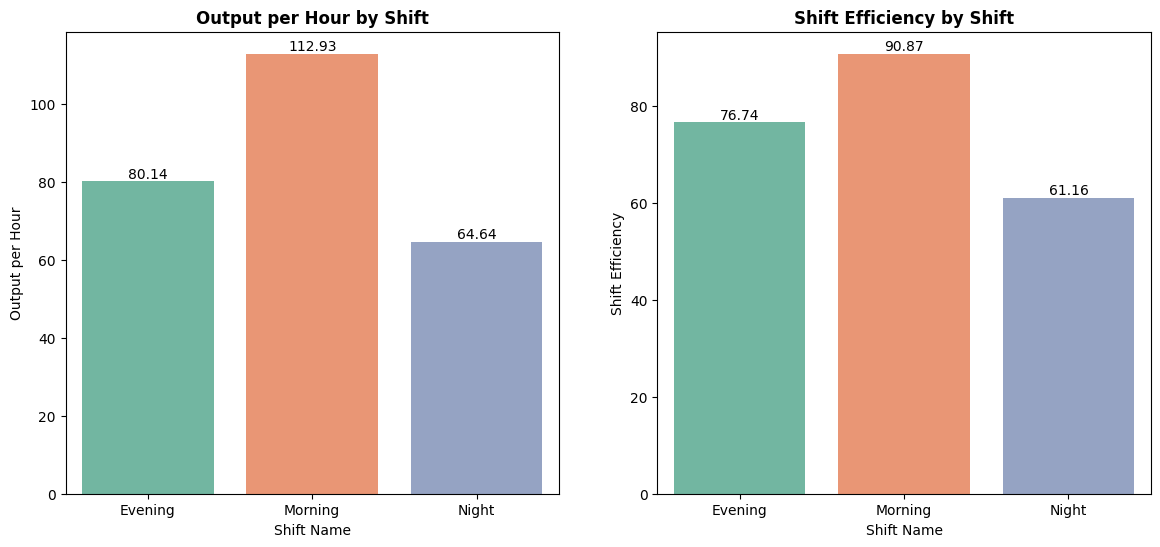

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x='shift_name', 
    y='output_per_hour',
    data=output_per_hour_data, 
    palette='Set2',
    ax=ax[0],
    hue='shift_name',
    legend=False
)

ax[0].set_title('Output per Hour by Shift', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Shift Name')
ax[0].set_ylabel('Output per Hour')

for i, v in enumerate(output_per_hour_data['output_per_hour'].values):
    ax[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')


merged_data = shift_performance_data.merge(output_per_hour_data, on='shift_name')
# Plot2, Plotting the shift efficiency score

sns.barplot(
    x='shift_name', 
    y='average_efficiency',
    data=merged_data, 
    palette='Set2',
    hue='shift_name',
    ax=ax[1],
    legend=False
)

ax[1].set_title('Shift Efficiency by Shift', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Shift Name')
ax[1].set_ylabel('Shift Efficiency')

for i, v in enumerate(merged_data['average_efficiency'].values):
    ax[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

In [33]:
prod = (
    shift_data[['production_id', 'shift_id', 'date', 'units_produced', 'defect_count']]
    .drop_duplicates(subset=['production_id'])
    .copy()
)

machine = (
    shift_data[["machine_id", "date", "shift_id", "downtime_minutes"]]
    .drop_duplicates()
    .copy()
)

In [34]:
prod.head()

,production_id,shift_id,date,units_produced,defect_count
0,1,1,2024-01-01,929,20
2308,102,3,2024-01-01,530,21
2309,103,3,2024-01-01,489,22
2331,104,3,2024-01-01,527,21
2281,101,3,2024-01-01,555,21


In [35]:
prod.shape

(13650, 5)

In [36]:
machine.head()

,machine_id,date,shift_id,downtime_minutes
0,MC_001,2024-01-01,1,15.39
2308,MC_002,2024-01-01,3,53.73
2309,MC_003,2024-01-01,3,51.90
2331,MC_004,2024-01-01,3,54.45
2281,MC_001,2024-01-01,3,52.99


In [37]:
machine.shape

(13650, 4)

### OEE metrics calculation

### OEE Calculation

The code calculates Overall Equipment Effectiveness (OEE) by:

1. **Separating production and machine data** - Creates distinct tables for production metrics (units, defects) and machine metrics (downtime)

2. **Computing three OEE components:**
   - **Availability** - Machine uptime percentage
   - **Performance** - Speed efficiency vs theoretical maximum  
   - **Quality** - Percentage of defect-free units

3. **Tracking monthly trends** - Calculates OEE per month and identifies performance degradation between months

**Why this matters:** OEE is a manufacturing industry standard that pinpoints whether productivity losses come from equipment downtime, slow operation speeds, or product defects.

## A Detailed Breakdown of what is happening:


A simple scenario breakdown of the OEE code and why it is important:

---

## Code Breakdown: A Factory Story

### Meet Our Factory

Imagine you run a **bottle factory**. Each machine should produce **100 bottles per hour** (theoretical rate). Each shift is **7.5 hours** (planned time).

---

### First Code Block: Organizing the Data

**Scenario:** You have a messy notebook with all your factory records mixed together.

```python
prod = (
    df[['production_id', 'shift_id', 'date', 'units_produced', 'defect_count']]
    .drop_duplicates(subset=['production_id'])
    .copy()
)
```

**What's happening:** You create a clean **Production Log** that shows:
- How many bottles were made
- How many were defective
- One entry per production run (no duplicates)

```python
mach = (
    df[['machine_id', 'shift_id', 'date', 'downtime_minutes']]
    .drop_duplicates()
    .copy()
)
```

**What's happening:** You create a separate **Maintenance Log** that shows:
- How many minutes each machine broke down
- Organized by machine, shift, and date

**Why separate them?** Because one machine might break down during multiple production runs. Keeping them separate prevents counting the same breakdown twice.

---

### Second Code Block: Calculating OEE (The Scorecard)

**Scenario:** Now you want to grade how well your factory performed each day.

#### Step 1: Calculate Availability (Was the machine running?)

```python
mach['avail_machine'] = 1 - mach['downtime_minutes']/(PLANNED*60)
```

**Simple explanation:** 
- Perfect score = 1.0 (100% available)
- Each minute of breakdown reduces the score

**Example:** 
- Your shift is 7.5 hours = 450 minutes
- Machine broke down for 45 minutes
- Availability = 1 - (45 ÷ 450) = 0.90 or 90%
- **Meaning:** Machine was running 90% of the time

#### Step 2: Calculate Performance (Did it run at full speed?)

```python
merged['performance'] = (merged['units_produced'] / (THEO * PLANNED)).clip(0,1)
```

**Simple explanation:**
- Perfect score = 1.0 (100% speed)
- Slower production reduces the score

**Example:**
- Theoretical speed = 100 bottles per hour
- Planned time = 7.5 hours
- Should have made: 100 × 7.5 = 750 bottles
- Actually made: 600 bottles
- Performance = 600 ÷ 750 = 0.80 or 80%
- **Meaning:** Machine ran at 80% of its target speed

#### Step 3: Calculate Quality (Were the bottles good?)

```python
merged['quality'] = 1 - merged['defect_count']/merged['units_produced']
```

**Simple explanation:**
- Perfect score = 1.0 (100% good products)
- Each defective product reduces the score

**Example:**
- Made 600 bottles
- 30 were cracked (defects)
- Quality = 1 - (30 ÷ 600) = 0.95 or 95%
- **Meaning:** 95% of bottles were good, 5% were defective

#### Step 4: Calculate Final OEE Score

```python
merged['oee_est'] = merged['availability'] * merged['performance'] * merged['quality']
```

**Example calculation:**
- Availability = 90% (0.90)
- Performance = 80% (0.80)
- Quality = 95% (0.95)

**OEE = 0.90 × 0.80 × 0.95 = 0.684 or 68.4%**

**What this means for the factory owner:**

| Score | Grade | What It Tells You |
|-------|-------|-------------------|
| 68.4% | C | You're losing 31.6% of potential production |
| | | - 10% lost to breakdowns |
| | | - 20% lost to slow speed |
| | | - 5% lost to defects |

---

### Monthly Tracking: Spotting Problems Early

```python
monthly_oee = merged.groupby('month')['oee_est'].mean()
```

**Scenario:** You track OEE for three months:

| Month | OEE | Change |
|-------|-----|--------|
| Month 1 | 75% | Starting point |
| Month 2 | 70% | ↓ 5% |
| Month 3 | 65% | ↓ 10% total |

```python
degradation = (m1 - m3) / m1 * 100
```

**Result:** 13.3% degradation

**What this tells you:** Something is getting worse over time. Machines might be aging, maintenance might be slipping, or operators might be struggling.

---

### The Big Picture: Why This Matters

**Without OEE:** "Our factory isn't producing enough" (vague problem)

**With OEE:** 
- "Availability is 90%" → Breakdowns are minimal ✓
- "Performance is 60%" → Machines running too slow ✗
- "Quality is 95%" → Defects are fine ✓

**Action Plan:** Focus on improving machine speed (performance), not breakdowns or quality.

---

### Summary Table

| OEE Component | Question It Answers | Example Problem |
|---------------|---------------------|-----------------|
| **Availability** | Was the machine running? | Breakdowns, changeovers |
| **Performance** | Was it running at full speed? | Slow operation, jams |
| **Quality** | Did it make good products? | Defects, scrap |
| **OEE** | Overall factory health? | Combined score |

**Perfect Factory (100% OEE):** 
- Machine never stops (100% availability)
- Always runs at full speed (100% performance)
- Every product is perfect (100% quality)

**Real World:** Most factories score 60-85%. The code helps you find exactly where you're losing points.

In [38]:
import os

PLANNED = globals().get('PLANNED_H', 7.5)
THEO = globals().get('THEO_RATE', 100.0)

# computer per machine availability
machine['available_machine'] = 1 - machine['downtime_minutes'] / (PLANNED * 60)
machine['available_machine'] = machine['available_machine'].clip(0, 1)

available_machine_agg = (
    machine.groupby(['date', 'shift_id'])['available_machine']
    .mean()
    .reset_index()
    .rename(columns = {'available_machine': 'machine_availability'})
)

In [39]:
available_machine_agg.head()

,date,shift_id,machine_availability
0,2024-01-01,1,0.963687
1,2024-01-01,2,0.920976
2,2024-01-01,3,0.881807
3,2024-01-02,1,0.965439
4,2024-01-02,2,0.919042


In [40]:
available_machine_agg.shape

(273, 3)

In [41]:
# merging availability into production
merged_production_data = prod.merge(available_machine_agg, how = "left", on = ["date", "shift_id"])
merged_production_data['machine_availability'] = merged_production_data['machine_availability'].fillna(1)

# performance based on the planned time (not runtime)
merged_production_data['performance'] = (merged_production_data['units_produced'] / (PLANNED * THEO)).clip(0, 1)

# Quality
merged_production_data['quality'] = 1 - (merged_production_data['defect_count'] / merged_production_data['units_produced'])
merged_production_data['quality'] = merged_production_data['quality'].fillna(1).clip(0, 1)

# Final OEE estimate
merged_production_data['oee_est'] = merged_production_data['machine_availability'] * merged_production_data['performance'] * merged_production_data['quality']

merged_production_data['month'] = merged_production_data['date'].dt.month

In [42]:
merged_production_data.head()

,production_id,shift_id,date,units_produced,defect_count,machine_availability,performance,quality,oee_est,month
0,1,1,2024-01-01,929,20,0.963687,1.000000,0.978471,0.942940,1
1,102,3,2024-01-01,530,21,0.881807,0.706667,0.960377,0.598453,1
2,103,3,2024-01-01,489,22,0.881807,0.652000,0.955010,0.549072,1
3,104,3,2024-01-01,527,21,0.881807,0.702667,0.960152,0.594926,1
4,101,3,2024-01-01,555,21,0.881807,0.740000,0.962162,0.627846,1


In [43]:
## monthly OEE (overall equipment effective for each of the month)
monthly_oee = (
    merged_production_data.groupby('month')['oee_est']
    .mean()
    .sort_index()
)

# print to confirm it matches the earlier value
for month, value in monthly_oee.items():
    print(f'Month: {month}, Average OEE: {value*100:.2f}%')

Month: 1, Average OEE: 74.90%
Month: 2, Average OEE: 68.53%
Month: 3, Average OEE: 68.83%


In [44]:
if 1 in monthly_oee.index and 3 in monthly_oee.index:
    m1 = monthly_oee.loc[1]
    m3 = monthly_oee.loc[3]
    degradation = (m1 - m3) / m1 * 100
    print(f'Quarterly degradation (month 1 month 3): {degradation:.2f}')
else:
    print('could not find month 1 and 3 in the data to compute the degradation process or curve')

Quarterly degradation (month 1 month 3): 8.10


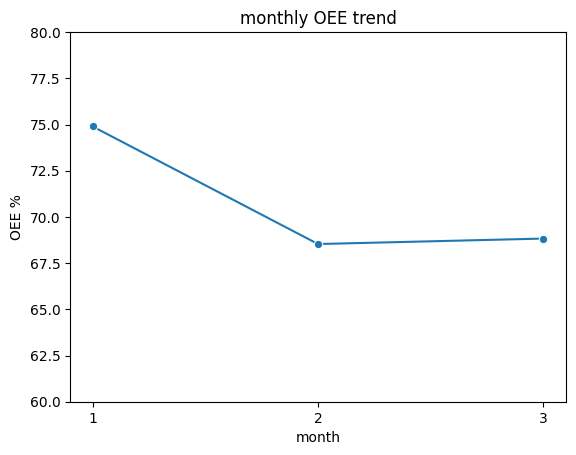

In [45]:
monthly_oee_df = monthly_oee.reset_index()
monthly_oee_df['oee_percentage'] = monthly_oee_df['oee_est'] * 100

sns.lineplot(
    x='month',
    y='oee_percentage',
    data=monthly_oee_df,
    marker='o'
    )
plt.title('monthly OEE trend')
plt.ylabel('OEE %')
plt.ylim(60, 80)
plt.xticks([1,2,3])
plt.xlabel('month')
plt.show()

#### Experience vs the defect count that occurred during production

C:\Users\Admin\AppData\Local\Temp\ipykernel_12332\2273647794.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


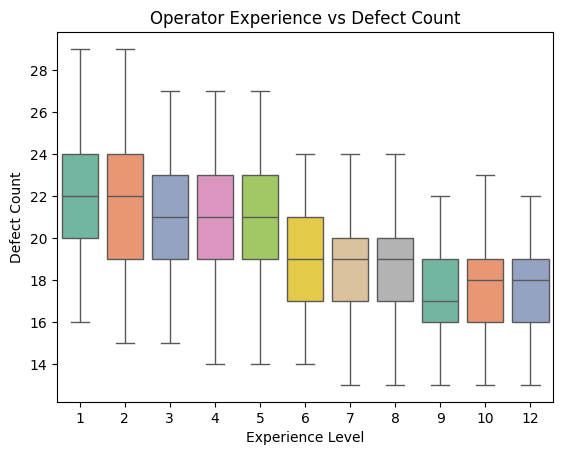

In [46]:
sns.boxplot(
    data=shift_data,
    x='experience_level',
    y='defect_count',
    palette='Set2'
    )
plt.title('Operator Experience vs Defect Count')
plt.xlabel('Experience Level')
plt.ylabel('Defect Count')
plt.show()

#### Feature Engineering

In [47]:
shift_data.shape

(296334, 31)

In [48]:
shift_data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'issue_type', 'maintenance_downtime', 'resolved_by',
       'qc_id', 'defect_type', 'severity', 'inspection_result', 'temperature',
       'humidity', 'timestamp', 'total_operation_hours'],
      dtype='object')

In [50]:
# Engineering new features
shift_data['start_time'] = pd.to_datetime(shift_data['start_time'])
shift_data['end_time'] = pd.to_datetime(shift_data['end_time'])
shift_data['date'] = pd.to_datetime(shift_data['date'])

#fixing the overnight shift and add 1 day where the end time less than start time
mask = shift_data['end_time'] < shift_data['start_time']
shift_data.loc[mask, 'end_time'] = shift_data.loc[mask, 'end_time'] + pd.Timedelta(days=1)

#shift duration
shift_data['shift_duration'] = (shift_data['end_time'] - shift_data['start_time']).dt.total_seconds() / 3600

#defect rate
shift_data['defect_rate'] = shift_data['defect_count'] / shift_data['units_produced'].replace(0, pd.NA)

#downtime rate
shift_data['downtime_rate'] = shift_data['downtime_minutes'] / (shift_data['shift_duration'] * 60)

#temperal features
shift_data['day_of_week'] = shift_data['date'].dt.dayofweek
shift_data['hour_of_day'] = shift_data['start_time'].dt.hour

In [51]:
# dropping identifiers, raw datetime columns and leakages

cols_to_drop = [
    #identifiers
    'shift_id', 'operator_id', 'operator_name', 'machine_id', 'production_id', 'supervisor_id',
    
    #leakage
    'qc_id', 'resolved_by', 'timestamp',

    # Raw datetime cols
    'start_time', 'end_time', 'date'
]


shift_data.drop(columns = cols_to_drop, inplace = True)
shift_data.shape

(296334, 24)

In [52]:
shift_data.duplicated().sum()

np.int64(119015)

In [53]:
shift_data.drop_duplicates(inplace=True)

### Modelling Phase

In [54]:
shift_data.isna().sum()

shift_name                0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
experience_level          0
skill_category            0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
total_operation_hours     0
shift_duration            0
defect_rate               0
downtime_rate             0
day_of_week               0
hour_of_day               0
dtype: int64

In [55]:
shift_data.head()

,shift_name,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,skill_category,runtime_hours,downtime_minutes,maintenance_flag,...,severity,inspection_result,temperature,humidity,total_operation_hours,shift_duration,defect_rate,downtime_rate,day_of_week,hour_of_day
0,Morning,929,20,35.65,95.945255,7,Expert,7.24,15.39,0,...,Minor,Rework,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,6
2308,Night,530,21,35.61,66.604731,5,Intermediate,6.60,53.73,0,...,Minor,Accepted,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,22
2309,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Major,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2310,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2311,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22


In [56]:
shift_data['shift_efficiency_score'].describe()

count    177319.000000
mean         75.829886
std          12.955768
min          41.690033
25%          64.595342
50%          76.253965
75%          87.578778
max         104.379285
Name: shift_efficiency_score, dtype: float64

In [58]:
shift_data.drop(['inspection_result'], axis=1)

,shift_name,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,skill_category,runtime_hours,downtime_minutes,maintenance_flag,...,defect_type,severity,temperature,humidity,total_operation_hours,shift_duration,defect_rate,downtime_rate,day_of_week,hour_of_day
0,Morning,929,20,35.65,95.945255,7,Expert,7.24,15.39,0,...,Material,Minor,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,6
2308,Night,530,21,35.61,66.604731,5,Intermediate,6.60,53.73,0,...,Surface,Minor,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,22
2309,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Cosmetic,Major,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2310,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Dimensional,Minor,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2311,Night,489,22,34.01,61.238523,2,Junior,6.64,51.90,0,...,Assembly,Minor,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294252,Evening,557,21,38.54,64.948418,3,Intermediate,6.47,61.65,0,...,Assembly,Minor,22.3,47.0,7.4975,8.0,0.037702,0.128438,6,14
294254,Evening,557,21,38.54,64.948418,3,Intermediate,6.47,61.65,0,...,Dimensional,Major,22.3,47.0,7.4975,8.0,0.037702,0.128438,6,14
294256,Evening,557,21,38.54,64.948418,3,Intermediate,6.47,61.65,0,...,Cosmetic,Major,22.3,47.0,7.4975,8.0,0.037702,0.128438,6,14
294257,Evening,557,21,38.54,64.948418,3,Intermediate,6.47,61.65,0,...,Material,Minor,22.3,47.0,7.4975,8.0,0.037702,0.128438,6,14


#### Data Splitting

In [59]:
x = shift_data.drop(columns=['shift_efficiency_score'])
y = shift_data['shift_efficiency_score']

In [60]:
x.head()

,shift_name,units_produced,defect_count,cycle_time_avg,experience_level,skill_category,runtime_hours,downtime_minutes,maintenance_flag,machine_status,...,severity,inspection_result,temperature,humidity,total_operation_hours,shift_duration,defect_rate,downtime_rate,day_of_week,hour_of_day
0,Morning,929,20,35.65,7,Expert,7.24,15.39,0,Operational,...,Minor,Rework,22.3,49.9,7.4965,8.0,0.021529,0.032063,0,6
2308,Night,530,21,35.61,5,Intermediate,6.60,53.73,0,Issues,...,Minor,Accepted,22.3,49.9,7.4955,8.0,0.039623,0.111937,0,22
2309,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,...,Major,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2310,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22
2311,Night,489,22,34.01,2,Junior,6.64,51.90,0,Issues,...,Minor,Rework,22.3,49.9,7.5050,8.0,0.044990,0.108125,0,22


In [61]:
y.head()

0       95.945255
2308    66.604731
2309    61.238523
2310    61.238523
2311    61.238523
Name: shift_efficiency_score, dtype: float64

In [63]:
# splitting into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [64]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [65]:
x.columns

Index(['shift_name', 'units_produced', 'defect_count', 'cycle_time_avg',
       'experience_level', 'skill_category', 'runtime_hours',
       'downtime_minutes', 'maintenance_flag', 'machine_status', 'issue_type',
       'maintenance_downtime', 'defect_type', 'severity', 'inspection_result',
       'temperature', 'humidity', 'total_operation_hours', 'shift_duration',
       'defect_rate', 'downtime_rate', 'day_of_week', 'hour_of_day'],
      dtype='object')

In [72]:
num_col = [
    'units_produced', 'defect_count', 'cycle_time_avg', 
    'runtime_hours', 'downtime_minutes', 'maintenance_downtime',
    'temperature', 'humidity'
]


In [73]:
cat_cols = ['shift_name', 'skill_category', 'machine_status', 'issue_type', 'defect_type', 'severity']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_col)
    ])

In [69]:
import mlflow
import mlflow.sklearn

import dagshub
dagshub.init(repo_owner='adamudaniel128', repo_name='Shift-Optimization-System', mlflow=True)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

Accessing as adamudaniel128

Initialized MLflow to track repo "adamudaniel128/Shift-Optimization-System"

Repository adamudaniel128/Shift-Optimization-System initialized!

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

models = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Random Forest': RandomForestRegressor()
}

results = {}
fitted_pipelines = {}  # Pluralized for clarity

mlflow.set_experiment('shift_optimisation_models')

for name, model in models.items():
    with mlflow.start_run(run_name=name):

        # 1. Dynamically create the pipeline
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        
        # 2. Train the pipeline
        pipeline.fit(X_train, y_train)
        
        # 3. Predict and Evaluate
        y_pred = pipeline.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        # Save to local dictionaries for quick access
        results[name] = {'mae': mae, 'mse': mse, 'r2': r2}
        fitted_pipelines[name] = pipeline

        # 4. Log model hyperparameters to MLflow automatically
        # Extracts specific parameters belonging to the model step inside the pipeline
        mlflow.log_params(model.get_params())

        # 5. Log evaluation metrics as a dictionary
        mlflow.log_metrics({
            'mae': mae,
            'mse': mse,
            'r2': r2
        })

        # 6. Log the pipeline artifact
        mlflow.sklearn.log_model(pipeline, artifact_path=f'model_{name.lower().replace(" ", "_")}')

        print(f"{name} - MAE: {mae:.4f}, MSE: {mse:.4f}, R2: {r2:.4f}")
        

2026/06/01 22:49:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 22:49:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression - MAE: 2.6853, MSE: 11.3883, R2: 0.9323
🏃 View run Linear Regression at: https://dagshub.com/adamudaniel128/Shift-Optimization-System.mlflow/#/experiments/0/runs/fb0b84fe06f64b6e9aeb8fc3697c1d56
🧪 View experiment at: https://dagshub.com/adamudaniel128/Shift-Optimization-System.mlflow/#/experiments/0


2026/06/01 22:52:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 22:52:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting - MAE: 2.4242, MSE: 9.2718, R2: 0.9449
🏃 View run Gradient Boosting at: https://dagshub.com/adamudaniel128/Shift-Optimization-System.mlflow/#/experiments/0/runs/d30991509f374f9d86630b5edb7d31e7
🧪 View experiment at: https://dagshub.com/adamudaniel128/Shift-Optimization-System.mlflow/#/experiments/0


2026/06/01 22:56:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 22:56:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest - MAE: 0.0033, MSE: 0.0003, R2: 1.0000
🏃 View run Random Forest at: https://dagshub.com/adamudaniel128/Shift-Optimization-System.mlflow/#/experiments/0/runs/1addf90879484055bdb0e8b9b255ed22
🧪 View experiment at: https://dagshub.com/adamudaniel128/Shift-Optimization-System.mlflow/#/experiments/0
